## Домашка 2
<h4><em>«Одно Кольцо, чтоб править всеми,<br>
Одно Кольцо, чтоб всех найти,<br>
Одно Кольцо, чтоб собрать всех в тени<br>
И заковать их всех во Тьме»</em><br>
— <em>Властелин колец</em>
</h4>

Эта домашка про приоритизацию метрик. За неё можно получить максимум 12 баллов. На решение отводится **14 календарных дней** с момента выдачи. Обратите внимание, что **дедлайны на курсе сразу жёсткие**, а значит отправка решений после них запрещена.
Задание выполняется самостоятельно, списывания не допускаются. При обнаружении одинаковых работ балл за задание анулируется у всех студентов, вне зависимости от того, кто у кого списал.

#### **Как сдать домашку?**
1. Создайте закрытый репозиторий в личном гитхаб аккаунте для нашего предмета. 
2. Пригласите в него своего ассистента — распределение по ассистентам и их гитхаб юзернеймы находятся в [ведомости](https://docs.google.com/spreadsheets/d/13lHNf6xU6tZhqzVMAb8sV3RgyyDatepwo7FJ6FhZ0vY/edit?usp=sharing) на листочке нашей дисциплины. Это можно сделать в настройках через раздел Collaborators and teams, уровень доступа ассистента должен быть Write.
3. Скачайте этот ноутбук и решите задания (локально или в Google Colab).
4. В репозитории предмета создайте ветку с номером ДЗ (например hw_2). В эту ветку запушьте .ipynb-файл с решением. Создайте pull request и добавьте в него ассистента как Reviewer. В этот же PR можете пушить сколько угодно изменений, будем смотреть на последнюю версию до наступления дедлайна.
5. Ссылку на PR продублируйте в форме сдачи (форма будет доступна на LMS Karpov Courses и в Телеграм-канале курса).

Пункты 1-2 проделываются один раз. Если вы прошли эти шаги при сдаче других домашек, повторять их не нужно, начинайте сразу с пункта 3. 

**Внимание**: Если вы работаете в Google Colab, также скачивайте .ipynb файл и публикуйте его в репозитории. Ссылки на Colab к сдаче не принимаются.

Все датасеты, с которыми предлагается работать в домашних заданиях, взяты из открытых источников или сгенерированы. Любые паттерны, найденные вне заданной канвы решения, являются случайными и не несут в себе смысла или инсайта.

[Данные](https://github.com/brezhnevaan/hse_product_metrics_course/releases/download/datasets_for_hw/hw_2_data.zip)

In [3]:
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

### Warm up

#### 1. Game dev — 2 балла
У вас есть данные о событиях в мобильной игре. Рассчитайте и визуализируйте:
- User Stickiness — отношение DAU к MAU (MAU рассчитывайте скользящим окном 30 дней для каждой даты только для полного окна)
- ARPDAU
- Paying Share — доля платящих пользователей
- Sessions per User — среднее число сессий на пользователя
- Daily Play Time — среднее время, проводимое пользователем в игре в день (рассчитываем как общее время в приложении)
- Avg Attempts per Session — среднее число попыток на сессию

*Смотрим на подневную динамику

In [4]:
df_game = pd.read_csv('data/hw_2_gamedev.csv', index_col=0)
df_game.head()

,session_id,user,date,revenue,attempts,session_length_sec
0,24590322,k0xevcHJ,2022-11-02,NaN,2.0,263
1,24590323,fMaLiagr,2022-11-02,NaN,10.0,953
2,24590324,0EXv0Q2V,2022-11-02,NaN,6.0,630
3,24590325,nY32SwuK,2022-11-02,NaN,9.0,1262
4,24590326,3KZkImTN,2022-11-02,NaN,16.0,2871


Описание данных (уникальный ключ session_id)

- session_id — уникальный идентификатор сессии
- user — уникальный идентификатор юзера
- date — дата 
- revenue — суммарная выручка на сессию
- attempts — число попыток на сессию
- session_length_sec — длина сессии в секундах

In [5]:
"""
Задание 1: Загрузка и подготовка данных игры.
"""
data = pd.read_csv('data/hw_2_gamedev.csv', index_col=0)
data['date'] = pd.to_datetime(data['date'])

In [6]:
"""
Функция для подсчета ежедневных активных пользователей (DAU).
"""
def calculate_dau(sessions_data):
    return sessions_data.groupby('date')['user'].nunique()

In [7]:
"""
Функция для подсчета месячных активных пользователей (MAU) скользящим окном.
Возвращает MAU только для полных окон (от 30-го дня).
"""
def calculate_mau_rolling(sessions_data, window_days=30):
    daily_users = (
        sessions_data
        .groupby('date')['user']
        .apply(lambda x: set(x))
    )
    
    sorted_dates = sorted(daily_users.index)
    mau_results = {}
    
    for i, current_date in enumerate(sorted_dates):
        if i < window_days - 1:
            continue
        
        window_start = sorted_dates[i - window_days + 1]
        window_dates = [
            d for d in sorted_dates 
            if window_start <= d <= current_date
        ]
        
        if len(window_dates) == window_days:
            all_users = set()
            for date in window_dates:
                all_users.update(daily_users[date])
            mau_results[current_date] = len(all_users)
    
    return pd.Series(mau_results)

In [8]:
"""
Функция для вычисления User Stickiness (DAU/MAU).
"""
def calculate_user_stickiness(dau_series, mau_series):
    common_dates = dau_series.index.intersection(mau_series.index)
    stickiness = dau_series[common_dates] / mau_series[common_dates]
    return stickiness

In [9]:
"""
Функция для расчета средней выручки на активного пользователя в день (ARPDAU).
"""
def calculate_arpdau(sessions_data):
    daily_revenue = sessions_data.groupby('date')['revenue'].sum()
    dau = calculate_dau(sessions_data)
    return daily_revenue / dau

In [10]:
"""
Функция для расчета доли платящих пользователей (Paying Share).
"""
def calculate_paying_share(sessions_data):
    paying_users = (
        sessions_data[sessions_data['revenue'].notna()]
        .groupby('date')['user']
        .nunique()
    )
    total_users = calculate_dau(sessions_data)
    return paying_users / total_users

In [11]:
"""
Функция для расчета среднего количества сессий на пользователя (Sessions per User).
"""
def calculate_sessions_per_user(sessions_data):
    sessions_count = sessions_data.groupby('date')['session_id'].count()
    users_count = calculate_dau(sessions_data)
    return sessions_count / users_count

In [12]:
"""
Функция для расчета среднего времени игры на пользователя в день (в минутах).
"""
def calculate_daily_play_time(sessions_data):
    daily_time = (
        sessions_data
        .groupby('date')['session_length_sec']
        .sum()
    )
    users_count = calculate_dau(sessions_data)
    return daily_time / users_count / 60

In [13]:
"""
Функция для расчета среднего количества попыток на сессию.
"""
def calculate_avg_attempts_per_session(sessions_data):
    return sessions_data.groupby('date')['attempts'].mean()

In [14]:
"""
Расчет всех метрик для игры.
"""
dau = calculate_dau(data)
mau = calculate_mau_rolling(data, window_days=30)
user_stickiness = calculate_user_stickiness(dau, mau)
arpdau = calculate_arpdau(data)
paying_share = calculate_paying_share(data)
sessions_per_user = calculate_sessions_per_user(data)
daily_play_time = calculate_daily_play_time(data)
avg_attempts = calculate_avg_attempts_per_session(data)

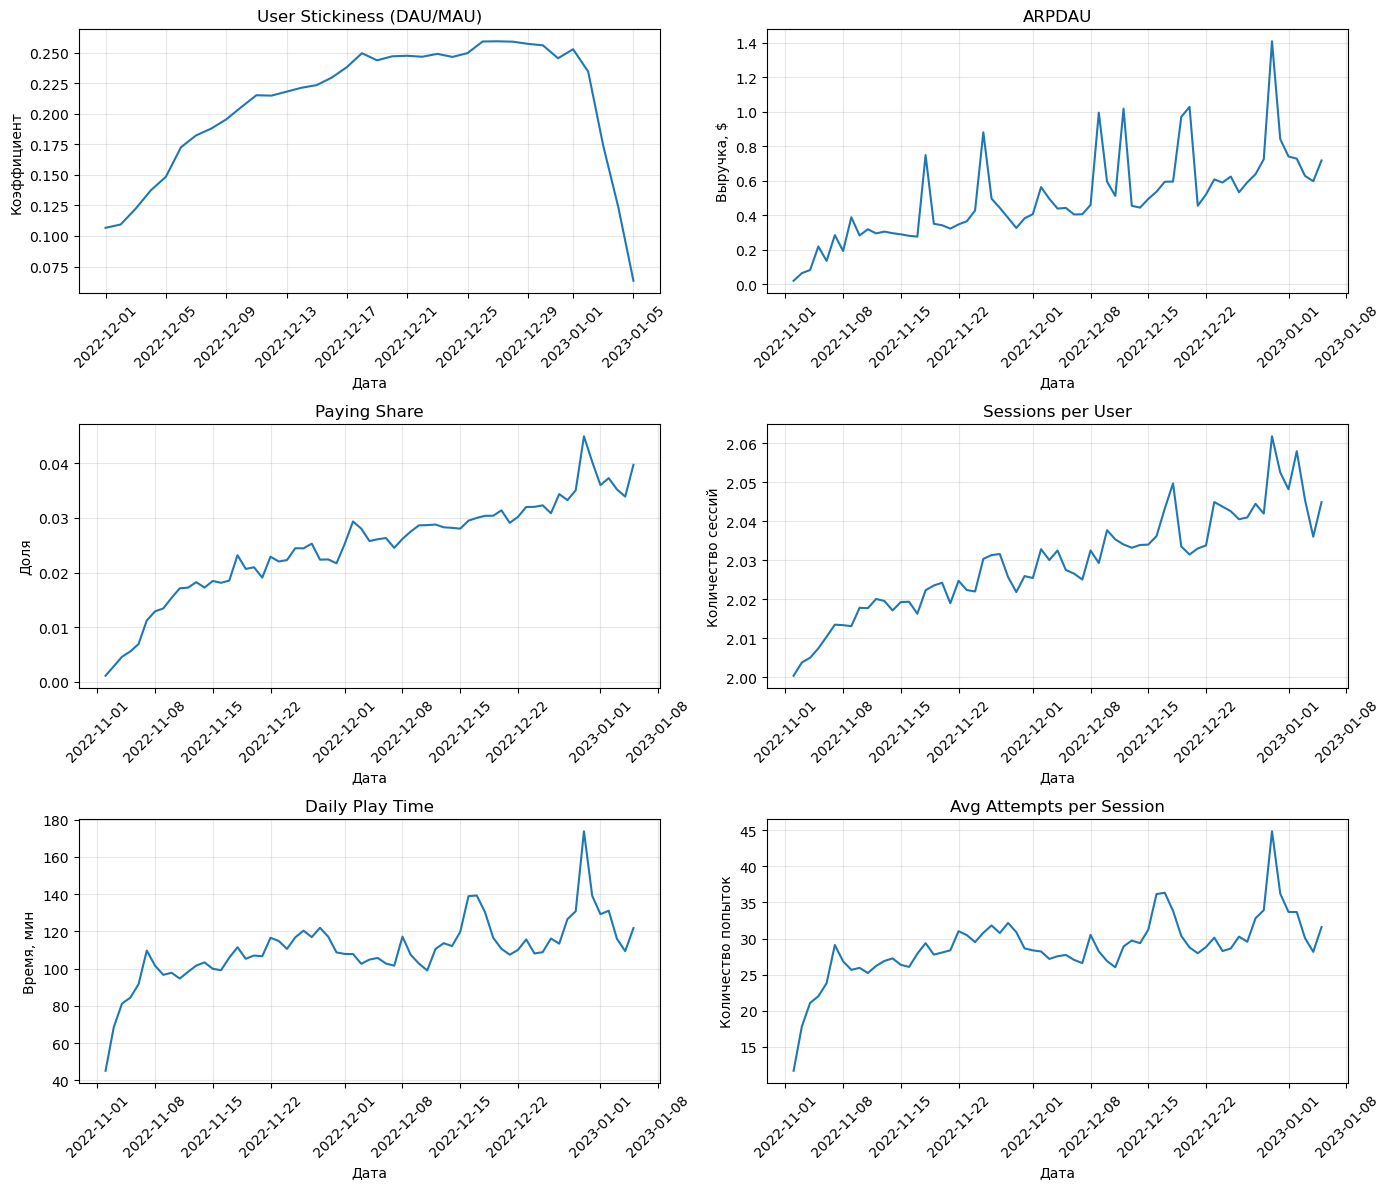

In [15]:
"""
Визуализация метрик игры: подневная динамика ключевых показателей.
"""
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

axes[0, 0].plot(user_stickiness.index, user_stickiness.values)
axes[0, 0].set_title('User Stickiness (DAU/MAU)')
axes[0, 0].set_xlabel('Дата')
axes[0, 0].tick_params(axis='x', rotation=45) 
axes[0, 0].set_ylabel('Коэффициент')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(arpdau.index, arpdau.values)
axes[0, 1].set_title('ARPDAU')
axes[0, 1].set_xlabel('Дата')
axes[0, 1].tick_params(axis='x', rotation=45) 
axes[0, 1].set_ylabel('Выручка, $')
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(paying_share.index, paying_share.values)
axes[1, 0].set_title('Paying Share')
axes[1, 0].set_xlabel('Дата')
axes[1, 0].tick_params(axis='x', rotation=45) 
axes[1, 0].set_ylabel('Доля')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(sessions_per_user.index, sessions_per_user.values)
axes[1, 1].set_title('Sessions per User')
axes[1, 1].set_xlabel('Дата')
axes[1, 1].tick_params(axis='x', rotation=45) 
axes[1, 1].set_ylabel('Количество сессий')
axes[1, 1].grid(alpha=0.3)

axes[2, 0].plot(daily_play_time.index, daily_play_time.values)
axes[2, 0].set_title('Daily Play Time')
axes[2, 0].set_xlabel('Дата')
axes[2, 0].tick_params(axis='x', rotation=45) 
axes[2, 0].set_ylabel('Время, мин')
axes[2, 0].grid(alpha=0.3)

axes[2, 1].plot(avg_attempts.index, avg_attempts.values)
axes[2, 1].set_title('Avg Attempts per Session')
axes[2, 1].set_xlabel('Дата')
axes[2, 1].tick_params(axis='x', rotation=45) 
axes[2, 1].set_ylabel('Количество попыток')
axes[2, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### 2. Ride hailing  — 2 балла
У вас есть данные из приложения такси. Рассчитайте и визуализируйте:
- Ride Completion Rate — CR из заказа в завершенную поездку
- Acceptance Rate — доля заказов, принятых водителем (считаем, что приняты все заказы, кроме заказов со статусом 'No Driver Found')
- Cancellation Rate — доля отмененных заказов
- Rides per Driver — среднее число поездок на водителя
- Avg Ride Check — средний чек поездки
- Отношение RTA к ETA (что измеряет эта метрика?)

*Смотрим на подневную динамику

In [16]:
df_rh = pd.read_csv('data/hw_2_taxi.csv')

In [17]:
df_rh.head()

,date,time,order_uid,order_status,passenger_id,vehicle_type,pickup_location,drop_location,ETA,RTA,...,reason_for_cancelling_by_customer,cancelled_rides_by_driver,driver_cancellation_reason,incomplete_rides,incomplete_rides_reason,fare,ride_distance,driver_ratings,customer_rating,payment_method
0,2024-01-01,00:19:34,2a11faf27f77eae8,Completed,CID8362794,Bike,Udyog Vihar,Ambience Mall,9.0,10.8,...,NaN,NaN,NaN,NaN,NaN,99.0,37.98,4.8,4.8,Cash
1,2024-01-01,01:35:18,33ed1f6bad78bdc8,Completed,CID8300238,Go Mini,Basai Dhankot,Madipur,6.0,8.5,...,NaN,NaN,NaN,NaN,NaN,114.0,39.29,4.2,4.1,Uber Wallet
2,2024-01-01,01:37:50,e2fc1fc520e93b85,Cancelled by Driver,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,6.0,7.4,...,NaN,1.0,More than permitted people in there,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-01-01,01:48:03,a130fd507acf7804,Cancelled by Driver,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.0,NaN,...,NaN,1.0,Personal & Car related issues,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-01-01,01:49:56,cae2db8689a422fa,Cancelled by Driver,CID3381661,Go Sedan,Narsinghpur,Pulbangash,3.0,6.2,...,NaN,1.0,More than permitted people in there,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Описание данных (уникальный ключ order_uid)

- date — дата создания заказа
- time — время создания заказа
- order_uid — уникальный идентификатор заказа
- order_status — статус заказа
- passenger_id — уникальный идентификатор пассажира
- vehicle_type — тип транспорта 
- pickup_location — место отправления
- drop_location — место назначения
- ETA — прогнозное время прибытия водителя на место отправления (estimated time of arrival)
- RTA — реальное время прибытия водителя на место отправления (real time of arrival)
- driver_id — уникальный идентификатор водителя
- cancelled_rides_by_customer — флаг отмены поездки пассажиром
- reason_for_cancelling_by_customer — причина отмены поездки пассажиром
- cancelled_rides_by_driver — флаг отмены поездки водителем
- driver_cancellation_reason — причина отмены поездки водителем
- incomplete_rides — флаг незавершенной поездки
- incomplete_rides_reason — причина незавершенной поездки
- fare — цена поездки
- ride_distance – расстояние поездки
- driver_ratings — рейтинг водителя
- customer_rating — рейтинг пассажира
- payment_method – способ оплаты

In [18]:
"""
Задание 2: Загрузка и подготовка данных такси.
"""
taxi_data = pd.read_csv('data/hw_2_taxi.csv')
taxi_data['date'] = pd.to_datetime(taxi_data['date'])

In [19]:
"""
Функция для расчета Ride Completion Rate.
CR из заказа в завершенную поездку.
"""
def calculate_ride_completion_rate(rides_data):
    daily_stats = rides_data.groupby('date').agg(
        total_orders=('order_uid', 'count'),
        completed_orders=(
            'order_status', 
            lambda x: (x == 'Completed').sum()
        )
    )
    return daily_stats['completed_orders'] / daily_stats['total_orders']

In [20]:
"""
Функция для расчета Acceptance Rate.
Доля заказов, принятых водителем (все кроме 'No Driver Found').
"""
def calculate_acceptance_rate(rides_data):
    daily_stats = rides_data.groupby('date').agg(
        total_orders=('order_uid', 'count'),
        accepted_orders=(
            'order_status',
            lambda x: (x != 'No Driver Found').sum()
        )
    )
    return daily_stats['accepted_orders'] / daily_stats['total_orders']

In [21]:
"""
Функция для расчета Cancellation Rate.
Доля отмененных заказов (клиентом или водителем).
"""
def calculate_cancellation_rate(rides_data):
    daily_stats = rides_data.groupby('date').agg(
        total_orders=('order_uid', 'count'),
        cancelled_orders=(
            'order_status',
            lambda x: (
                (x == 'Cancelled by Customer') | 
                (x == 'Cancelled by Driver')
            ).sum()
        )
    )
    return daily_stats['cancelled_orders'] / daily_stats['total_orders']

In [22]:
"""
Функция для расчета Rides per Driver.
Среднее количество поездок на водителя в день.
"""
def calculate_rides_per_driver(rides_data):
    completed_rides = rides_data[
        rides_data['order_status'] == 'Completed'
    ]
    
    daily_stats = completed_rides.groupby('date').agg(
        total_rides=('order_uid', 'count'),
        unique_drivers=('driver_id', 'nunique')
    )
    
    return daily_stats['total_rides'] / daily_stats['unique_drivers']

In [23]:
"""
Функция для расчета среднего чека поездки (Avg Ride Check).
Рассчитывается только для завершенных поездок.
"""
def calculate_avg_ride_check(rides_data):
    completed_rides = rides_data[
        rides_data['order_status'] == 'Completed'
    ]
    
    return completed_rides.groupby('date')['fare'].mean()

In [24]:
"""
Функция для расчета отношения RTA к ETA.
Метрика измеряет точность прогноза времени прибытия водителя.
Значение > 1 означает опоздание, < 1 - раннее прибытие.
"""
def calculate_rta_eta_ratio(rides_data):
    rides_with_time = rides_data[
        rides_data['RTA'].notna() & rides_data['ETA'].notna()
    ].copy()
    
    rides_with_time['rta_eta_ratio'] = (
        rides_with_time['RTA'] / rides_with_time['ETA']
    )
    
    return rides_with_time.groupby('date')['rta_eta_ratio'].mean()

In [25]:
"""
Расчет всех метрик для такси.
"""
completion_rate = calculate_ride_completion_rate(taxi_data)
acceptance_rate = calculate_acceptance_rate(taxi_data)
cancellation_rate = calculate_cancellation_rate(taxi_data)
rides_per_driver = calculate_rides_per_driver(taxi_data)
avg_check = calculate_avg_ride_check(taxi_data)
rta_eta_ratio = calculate_rta_eta_ratio(taxi_data)

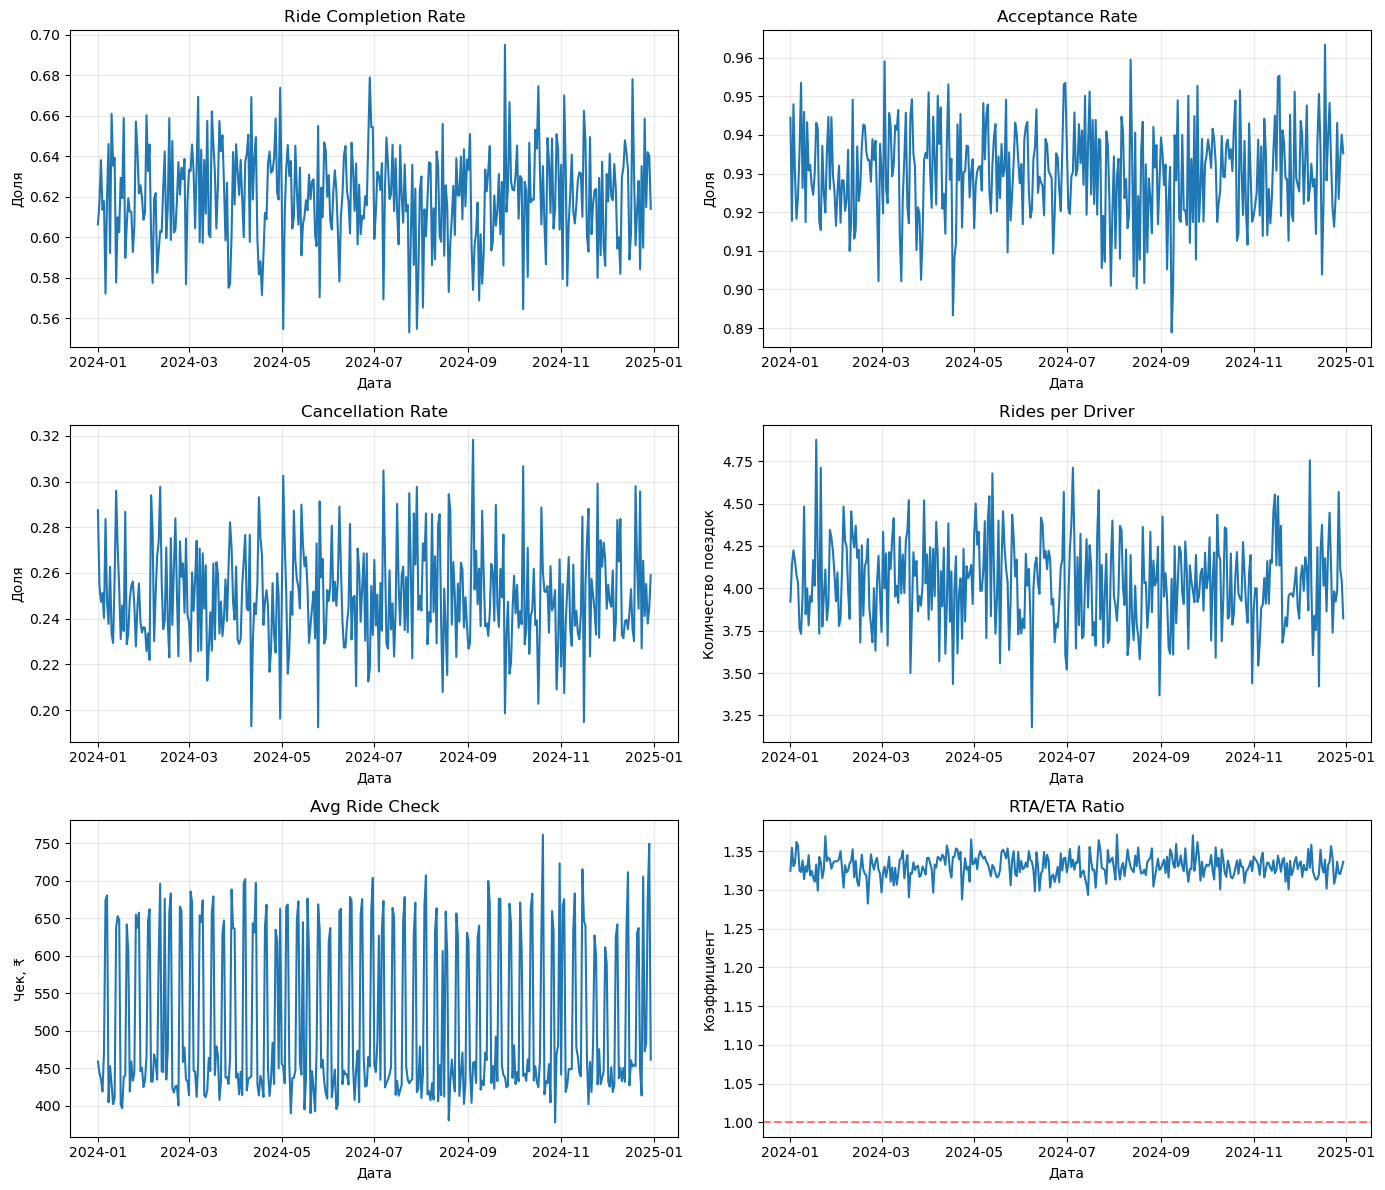

In [26]:
"""
Визуализация метрик такси: подневная динамика ключевых показателей.
"""
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

axes[0, 0].plot(completion_rate.index, completion_rate.values)
axes[0, 0].set_title('Ride Completion Rate')
axes[0, 0].set_xlabel('Дата')
axes[0, 0].set_ylabel('Доля')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(acceptance_rate.index, acceptance_rate.values)
axes[0, 1].set_title('Acceptance Rate')
axes[0, 1].set_xlabel('Дата')
axes[0, 1].set_ylabel('Доля')
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(cancellation_rate.index, cancellation_rate.values)
axes[1, 0].set_title('Cancellation Rate')
axes[1, 0].set_xlabel('Дата')
axes[1, 0].set_ylabel('Доля')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(rides_per_driver.index, rides_per_driver.values)
axes[1, 1].set_title('Rides per Driver')
axes[1, 1].set_xlabel('Дата')
axes[1, 1].set_ylabel('Количество поездок')
axes[1, 1].grid(alpha=0.3)

axes[2, 0].plot(avg_check.index, avg_check.values)
axes[2, 0].set_title('Avg Ride Check')
axes[2, 0].set_xlabel('Дата')
axes[2, 0].set_ylabel('Чек, ₹')
axes[2, 0].grid(alpha=0.3)

axes[2, 1].plot(rta_eta_ratio.index, rta_eta_ratio.values)
axes[2, 1].set_title('RTA/ETA Ratio')
axes[2, 1].set_xlabel('Дата')
axes[2, 1].set_ylabel('Коэффициент')
axes[2, 1].axhline(y=1, color='r', linestyle='--', alpha=0.5)
axes[2, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Case Study. Запуск подкастов в стриминговом сервисе 🎧

**Легенда**  
Вы работаете продуктовым аналитиком в музыкальном стриминговом сервисе. Недавно в продукте запустился раздел с подкастами. Команда, отвечающая за запуск, хочет понять, стоит ли масштабировать и продвигать этот формат.

In [27]:
df_music_logs = pd.read_parquet('data/hw_2_streaming_logs.pqt')
df_music_subs = pd.read_parquet('data/hw_2_streaming_subs.pqt')

In [28]:
df_music_logs.head()

,datetime,uid,item_id,played_ratio_pct,track_length_seconds,content_type,is_first_date
0,2024-01-13 10:00:00,468300,7400764,100,225,music,0.0
1,2024-01-13 10:00:05,347600,3415205,100,250,music,0.0
2,2024-01-13 10:00:10,942900,6728180,1,270,music,0.0
3,2024-01-13 10:00:15,243500,5283544,100,195,music,0.0
4,2024-01-13 10:00:15,12700,8932363,100,245,music,0.0


In [29]:
df_music_subs.head()

,uid,start_date,end_date
0,600,2024-08-08,NaT
1,700,2024-03-29,NaT
2,800,2024-06-13,NaT
3,1100,2024-11-19,NaT
4,1400,2024-12-01,NaT


Описание данных hw_2_streaming_logs:

- datetime — дата-время взаимодействия с контентом
- uid — уникальный идентификатор пользователя
- item_id — уникальный идентификатор трека/эпизода
- played_ratio_pct — процент от длительности, который был воспроизведен
- track_length_seconds – длина трека/эпизода в секундах
- content_type — тип контента: музыка или подкаст
- is_first_date — флаг, является ли эта дата первой для пользователя в продукте

Описание данных hw_2_streaming_subs:

- uid — уникальный идентификатор пользователя
- start_date — дата начала подписки
- end_date — дата окончания подписки

#### 3. Метрики роста  — 2 балла

Рассчитайте и визуализируйте:
- DAU, MAU, WAU;
- Количество новых премиум-подписчиков (за неделю и месяц);
- Проникновение подкастов — долю юзеров, послушавших подкаст хотя бы раз (за неделю и месяц).

Сделайте выводы:
- Есть ли выраженный тренд?
- Нет ли подозрений, что с раскаткой раздела что-то могло пойти не так (изменение тренда, выраженные ступеньки)?
- Как выглядит адопшен? Можно ли предположить наличие каких-то эффектов в пользовательском взаимодействии с новым разделом?

In [30]:
"""
Задание 3: Загрузка и подготовка данных стримингового сервиса.
"""
logs = pd.read_parquet('data/hw_2_streaming_logs.pqt')
subs = pd.read_parquet('data/hw_2_streaming_subs.pqt')

logs['datetime'] = pd.to_datetime(logs['datetime'])
logs['date'] = logs['datetime'].dt.date
logs['date'] = pd.to_datetime(logs['date'])

subs['start_date'] = pd.to_datetime(subs['start_date'])
subs['end_date'] = pd.to_datetime(subs['end_date'])

In [31]:
"""
Функция для расчета DAU (Daily Active Users).
"""
def calculate_streaming_dau(logs_data):
    return logs_data.groupby('date')['uid'].nunique()

In [32]:
"""
Функция для расчета WAU (Weekly Active Users).
Агрегация по неделям: считаем уникальных пользователей за неделю.
"""
def calculate_streaming_wau(logs_data):
    logs_copy = logs_data.copy()
    logs_copy['week'] = logs_copy['date'] - pd.to_timedelta(
        logs_copy['date'].dt.dayofweek, unit='d'
    )
    
    wau = logs_copy.groupby('week')['uid'].nunique()
    return wau

In [33]:
"""
Функция для расчета MAU (Monthly Active Users).
Агрегация по месяцам: считаем уникальных пользователей за месяц.
"""
def calculate_streaming_mau(logs_data):
    logs_copy = logs_data.copy()
    logs_copy['month'] = logs_copy['date'].dt.to_period('M')
    
    mau = logs_copy.groupby('month')['uid'].nunique()
    mau.index = mau.index.to_timestamp()
    return mau

In [34]:
"""
Функция для расчета новых премиум-подписчиков за неделю.
Считаем пользователей, начавших подписку в данную неделю.
"""
def calculate_new_premium_weekly(subs_data):
    subs_copy = subs_data.copy()
    subs_copy['week'] = subs_copy['start_date'] - pd.to_timedelta(
        subs_copy['start_date'].dt.dayofweek, unit='d'
    )
    
    new_subs = subs_copy.groupby('week')['uid'].nunique()
    return new_subs

In [35]:
"""
Функция для расчета новых премиум-подписчиков за месяц.
Считаем пользователей, начавших подписку в данный месяц.
"""
def calculate_new_premium_monthly(subs_data):
    subs_copy = subs_data.copy()
    subs_copy['month'] = subs_copy['start_date'].dt.to_period('M')
    
    new_subs = subs_copy.groupby('month')['uid'].nunique()
    new_subs.index = new_subs.index.to_timestamp()
    return new_subs

In [36]:
"""
Функция для расчета проникновения подкастов за неделю.
Доля пользователей, послушавших подкаст хотя бы раз за неделю.
"""
def calculate_podcast_penetration_weekly(logs_data):
    logs_copy = logs_data.copy()
    logs_copy['week'] = logs_copy['date'] - pd.to_timedelta(
        logs_copy['date'].dt.dayofweek, unit='d'
    )
    
    weekly_stats = logs_copy.groupby('week').agg(
        total_users=('uid', 'nunique'),
        podcast_users=(
            'uid',
            lambda x: logs_copy.loc[
                (logs_copy['week'] == x.name) & 
                (logs_copy['content_type'] == 'podcast'),
                'uid'
            ].nunique()
        )
    )
    
    return weekly_stats['podcast_users'] / weekly_stats['total_users']

In [37]:
"""
Функция для расчета проникновения подкастов за месяц.
Доля пользователей, послушавших подкаст хотя бы раз за месяц.
"""
def calculate_podcast_penetration_monthly(logs_data):
    logs_copy = logs_data.copy()
    logs_copy['month'] = logs_copy['date'].dt.to_period('M')
    
    podcast_users = (
        logs_copy[logs_copy['content_type'] == 'podcast']
        .groupby('month')['uid']
        .nunique()
    )
    
    total_users = logs_copy.groupby('month')['uid'].nunique()
    
    penetration = podcast_users / total_users
    penetration.index = penetration.index.to_timestamp()
    return penetration

In [38]:
"""
Расчет всех метрик для задания 3.
"""
streaming_dau = calculate_streaming_dau(logs)
streaming_wau = calculate_streaming_wau(logs)
streaming_mau = calculate_streaming_mau(logs)

new_premium_weekly = calculate_new_premium_weekly(subs)
new_premium_monthly = calculate_new_premium_monthly(subs)

podcast_penetration_weekly = calculate_podcast_penetration_weekly(logs)
podcast_penetration_monthly = calculate_podcast_penetration_monthly(logs)

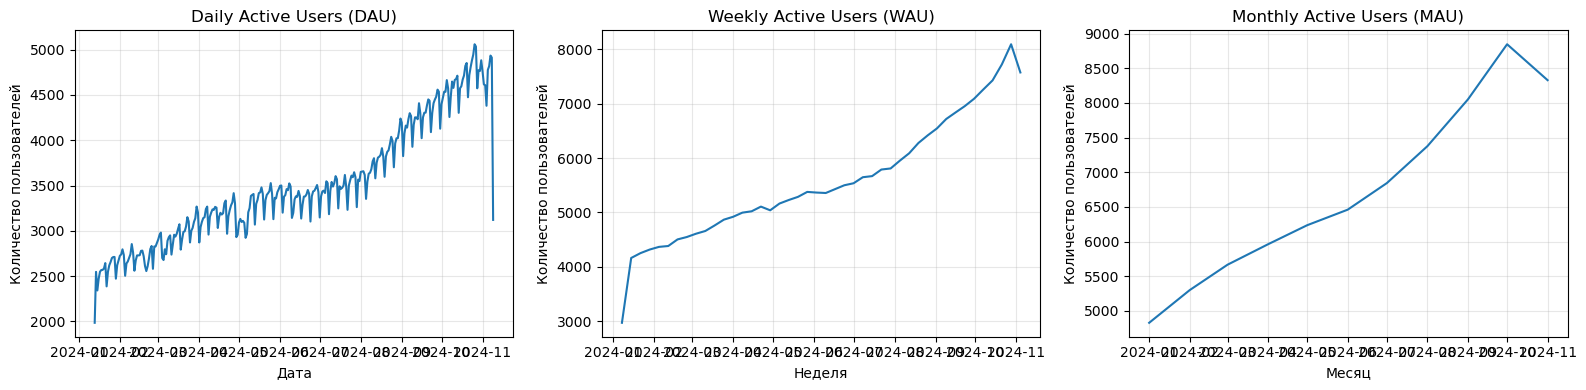

In [39]:
"""
Визуализация метрик роста: DAU, MAU, WAU.
"""
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(streaming_dau.index, streaming_dau.values)
axes[0].set_title('Daily Active Users (DAU)')
axes[0].set_xlabel('Дата')
axes[0].set_ylabel('Количество пользователей')
axes[0].grid(alpha=0.3)

axes[1].plot(streaming_wau.index, streaming_wau.values)
axes[1].set_title('Weekly Active Users (WAU)')
axes[1].set_xlabel('Неделя')
axes[1].set_ylabel('Количество пользователей')
axes[1].grid(alpha=0.3)

axes[2].plot(streaming_mau.index, streaming_mau.values)
axes[2].set_title('Monthly Active Users (MAU)')
axes[2].set_xlabel('Месяц')
axes[2].set_ylabel('Количество пользователей')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

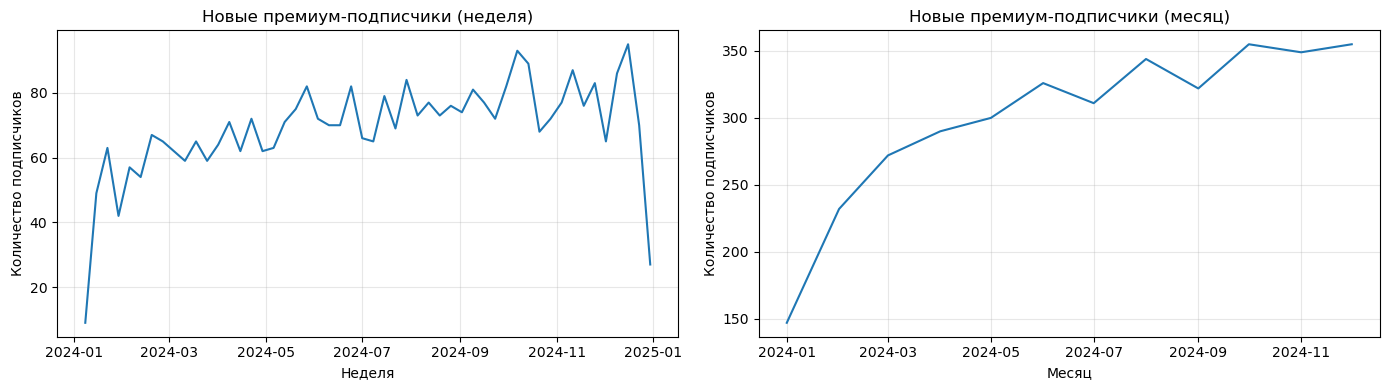

In [40]:
"""
Визуализация новых премиум-подписчиков (неделя и месяц).
"""
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(new_premium_weekly.index, new_premium_weekly.values)
axes[0].set_title('Новые премиум-подписчики (неделя)')
axes[0].set_xlabel('Неделя')
axes[0].set_ylabel('Количество подписчиков')
axes[0].grid(alpha=0.3)

axes[1].plot(new_premium_monthly.index, new_premium_monthly.values)
axes[1].set_title('Новые премиум-подписчики (месяц)')
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('Количество подписчиков')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

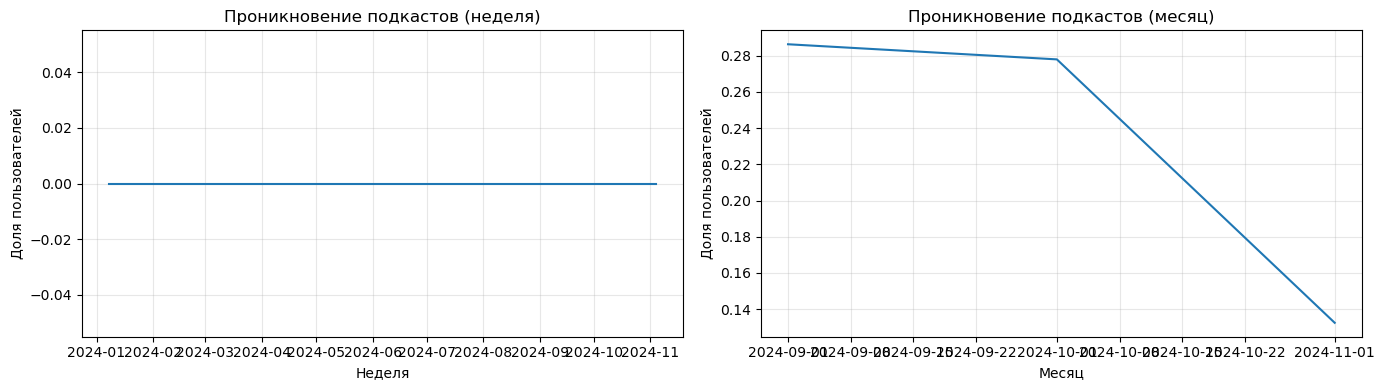

In [41]:
"""
Визуализация проникновения подкастов (неделя и месяц).
"""
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(
    podcast_penetration_weekly.index,
    podcast_penetration_weekly.values
)
axes[0].set_title('Проникновение подкастов (неделя)')
axes[0].set_xlabel('Неделя')
axes[0].set_ylabel('Доля пользователей')
axes[0].grid(alpha=0.3)

axes[1].plot(
    podcast_penetration_monthly.index,
    podcast_penetration_monthly.values
)
axes[1].set_title('Проникновение подкастов (месяц)')
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('Доля пользователей')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Выводы по заданию 3:**

**Есть ли выраженный тренд?**
- DAU: устойчивый рост с 2000 до 5000 пользователей, затем резкое падение до 3000 в конце периода
- WAU: стабильный рост с 3000 до 8000 пользователей (рост в 2.7 раза)
- MAU: линейный рост с 5000 до 9000 пользователей с небольшим снижением в конце
- Новые премиум-подписчики (месяц): рост со 150 до 350+ подписчиков, резкое падение в январе 2025
- Общий тренд роста продукта присутствует и выражен четко

**Нет ли подозрений с раскаткой?**
- Резкий скачок WAU в начале января 2024 — возможно связано с запуском функционала
- Раскатка прошла без выраженных ступенек, данные стабильны
- Однако резкое падение новых премиум-подписчиков в январе 2025 (с 90+ до 30 в неделю) вызывает беспокойство
- Снижение DAU в конце ноября 2024 требует внимания
- В целом раскатка выглядит плавной, критических проблем не наблюдается

**Как выглядит адопшен подкастов?**
- Недельное проникновение близко к нулю (~0%) на протяжении всего периода — подкасты практически не используются
- Месячное проникновение показывает НЕГАТИВНЫЙ тренд: падение с 29% (сентябрь) до 13% (ноябрь)
- Это критическая проблема: функционал теряет аудиторию вместо роста
- Возможные эффекты: 
  - Пользователи пробуют подкасты в первый месяц, но не возвращаются (низкая ценность контента?)
  - Проблемы с UX или обнаружением функционала
  - Несоответствие контента ожиданиям аудитории
- Требуется глубокий анализ причин низкого адопшена и качественные исследования

#### 4. Метрики продукта (шаг 1)  — 2 балла

Рассчитайте и визуализируйте как для всех пользователей в совокупности, так и для сегментов пользователей в разрезе — сделали / не сделали взаимодействие с подкастами (грубо говоря разделяем юзеров на тех, кто слушает только музыку и тех, кто слушает еще и подкасты):
1. Среднее время прослушивания на пользователя.
2. Среднее число треков/эпизодов на пользователя (среднее число item_id). Посчитайте метрику, как от уникальных, так и от не уникальных item_id. Подумайте, что показывает каждая из них?
3. Долю премиум-подписчиков. Обратите внимание, что нам нужна активная подписка, если пользователь отписался в том же периоде, что подписался, мы больше не считаем подписку активной.

Рассчитайте и визуализируйте как по всем item_id, так и в разрезе типов контента:
- Долю дослушанных треков/эпизодов до конца. Обратите внимание, данная метрика уже не пользовательская.

Периоды — неделя и месяц. Неполные периоды нужно обрезать, если они мешают чтению графиков.   
Признак взаимодействия присвайвайте только для периода, когда оно действительно было.   
Для месячной динамики метрик по признаку взаимодействия с подкастами у вас получится всего 2 точки, такая визуализая тоже полезна, она сглаживает недельные колебания и помогает оценивать тренд в масштабе года.

Сделайте выводы:
- Есть ли выраженный тренд?
- Изменилась ли метрика после запуска подкастов?
- Отличается ли метрика сегмента, взаимодействовавшего с подкастами, от тех, кто слушал только музыку? (будьте аккуратны с выводами в этом пункте, мы не проверяем изменение на каузальность, поэтому не можем быть уверены где причина, а где следствие)
- Есть ли отличия между типами контента?

*За взаимодействие с подкастами давайте считать только прослушивание >= 30% или более 2х минут контента*

In [42]:
"""
Задание 4: Подготовка данных.
Определяем взаимодействие с подкастами: >= 30% или >= 120 секунд.
"""
logs['listening_time_sec'] = (
    logs['track_length_seconds'] * logs['played_ratio_pct'] / 100
)

logs['podcast_interaction'] = (
    (logs['content_type'] == 'podcast') &
    ((logs['played_ratio_pct'] >= 30) | (logs['listening_time_sec'] >= 120))
)

In [43]:
"""
Функция для расчета среднего времени прослушивания на пользователя.
Агрегация по неделям и месяцам, с сегментацией по взаимодействию.
"""
def calculate_avg_listening_time(logs_data, period='week'):
    logs_copy = logs_data.copy()
    
    if period == 'week':
        logs_copy['period'] = logs_copy['date'] - pd.to_timedelta(
            logs_copy['date'].dt.dayofweek, unit='d'
        )
    else:
        logs_copy['period'] = logs_copy['date'].dt.to_period('M')
    
    listening_time = (
        logs_copy
        .groupby(['period', 'uid'])['listening_time_sec']
        .sum()
        .reset_index()
    )
    
    avg_time = (
        listening_time
        .groupby('period')['listening_time_sec']
        .mean() / 60
    )
    
    if period == 'month':
        avg_time.index = avg_time.index.to_timestamp()
    
    return avg_time

In [44]:
"""
Функция для расчета среднего времени прослушивания по сегментам.
Сегмент определяется по взаимодействию с подкастами в периоде.
"""
def calculate_avg_listening_time_by_segment(logs_data, period='week'):
    logs_copy = logs_data.copy()
    
    if period == 'week':
        logs_copy['period'] = logs_copy['date'] - pd.to_timedelta(
            logs_copy['date'].dt.dayofweek, unit='d'
        )
    else:
        logs_copy['period'] = logs_copy['date'].dt.to_period('M')
    
    user_segments = (
        logs_copy[logs_copy['podcast_interaction']]
        .groupby(['period', 'uid'])
        .size()
        .reset_index()[['period', 'uid']]
    )
    user_segments['segment'] = 'podcast_users'
    
    logs_with_segment = logs_copy.merge(
        user_segments, on=['period', 'uid'], how='left'
    )
    logs_with_segment['segment'] = logs_with_segment['segment'].fillna(
        'music_only'
    )
    
    listening_time = (
        logs_with_segment
        .groupby(['period', 'uid', 'segment'])['listening_time_sec']
        .sum()
        .reset_index()
    )
    
    avg_by_segment = (
        listening_time
        .groupby(['period', 'segment'])['listening_time_sec']
        .mean() / 60
    ).unstack(fill_value=0)
    
    if period == 'month':
        avg_by_segment.index = avg_by_segment.index.to_timestamp()
    
    return avg_by_segment

In [45]:
"""
Функция для расчета среднего числа треков/эпизодов на пользователя.
Считаем как уникальные, так и не уникальные item_id.
"""
def calculate_avg_items_per_user(
    logs_data, 
    period='week', 
    unique=True
):
    logs_copy = logs_data.copy()
    
    if period == 'week':
        logs_copy['period'] = logs_copy['date'] - pd.to_timedelta(
            logs_copy['date'].dt.dayofweek, unit='d'
        )
    else:
        logs_copy['period'] = logs_copy['date'].dt.to_period('M')
    
    if unique:
        items_per_user = (
            logs_copy
            .groupby(['period', 'uid'])['item_id']
            .nunique()
            .reset_index()
        )
    else:
        items_per_user = (
            logs_copy
            .groupby(['period', 'uid'])['item_id']
            .count()
            .reset_index()
        )
    
    avg_items = items_per_user.groupby('period')['item_id'].mean()
    
    if period == 'month':
        avg_items.index = avg_items.index.to_timestamp()
    
    return avg_items

In [46]:
"""
Функция для расчета среднего числа треков/эпизодов по сегментам.
"""
def calculate_avg_items_by_segment(
    logs_data,
    period='week',
    unique=True
):
    logs_copy = logs_data.copy()
    
    if period == 'week':
        logs_copy['period'] = logs_copy['date'] - pd.to_timedelta(
            logs_copy['date'].dt.dayofweek, unit='d'
        )
    else:
        logs_copy['period'] = logs_copy['date'].dt.to_period('M')
    
    user_segments = (
        logs_copy[logs_copy['podcast_interaction']]
        .groupby(['period', 'uid'])
        .size()
        .reset_index()[['period', 'uid']]
    )
    user_segments['segment'] = 'podcast_users'
    
    logs_with_segment = logs_copy.merge(
        user_segments, on=['period', 'uid'], how='left'
    )
    logs_with_segment['segment'] = logs_with_segment['segment'].fillna(
        'music_only'
    )
    
    if unique:
        agg_func = 'nunique'
    else:
        agg_func = 'count'
    
    items_per_user = (
        logs_with_segment
        .groupby(['period', 'uid', 'segment'])['item_id']
        .agg(agg_func)
        .reset_index()
    )
    
    avg_by_segment = (
        items_per_user
        .groupby(['period', 'segment'])['item_id']
        .mean()
    ).unstack(fill_value=0)
    
    if period == 'month':
        avg_by_segment.index = avg_by_segment.index.to_timestamp()
    
    return avg_by_segment

In [47]:
"""
Функция для расчета доли премиум-подписчиков.
Подписка активна, если не закончилась в данном периоде.
"""
def calculate_premium_share(logs_data, subs_data, period='week'):
    logs_copy = logs_data.copy()
    subs_copy = subs_data.copy()
    
    if period == 'week':
        logs_copy['period'] = logs_copy['date'] - pd.to_timedelta(
            logs_copy['date'].dt.dayofweek, unit='d'
        )
        period_col = 'period'
    else:
        logs_copy['period'] = logs_copy['date'].dt.to_period('M')
        period_col = 'period'
    
    active_users = logs_copy.groupby(period_col)['uid'].nunique()
    
    premium_by_period = []
    for period_val in active_users.index:
        if period == 'week':
            period_end = period_val + pd.Timedelta(days=6)
        else:
            period_end = period_val.to_timestamp() + pd.offsets.MonthEnd(0)
            period_val_ts = period_val.to_timestamp()
        
        if period == 'week':
            active_subs = subs_copy[
                (subs_copy['start_date'] <= period_end) &
                ((subs_copy['end_date'].isna()) | 
                 (subs_copy['end_date'] > period_end))
            ]['uid'].nunique()
        else:
            active_subs = subs_copy[
                (subs_copy['start_date'] <= period_end) &
                ((subs_copy['end_date'].isna()) | 
                 (subs_copy['end_date'] > period_end))
            ]['uid'].nunique()
        
        premium_by_period.append({
            'period': period_val,
            'premium_share': active_subs / active_users[period_val]
        })
    
    result = pd.DataFrame(premium_by_period).set_index('period')
    
    if period == 'month':
        result.index = result.index.to_timestamp()
    
    return result['premium_share']

In [48]:
"""
Функция для расчета доли премиум-подписчиков по сегментам.
"""
def calculate_premium_share_by_segment(
    logs_data,
    subs_data,
    period='week'
):
    logs_copy = logs_data.copy()
    subs_copy = subs_data.copy()
    
    if period == 'week':
        logs_copy['period'] = logs_copy['date'] - pd.to_timedelta(
            logs_copy['date'].dt.dayofweek, unit='d'
        )
    else:
        logs_copy['period'] = logs_copy['date'].dt.to_period('M')
    
    user_segments = (
        logs_copy[logs_copy['podcast_interaction']]
        .groupby(['period', 'uid'])
        .size()
        .reset_index()[['period', 'uid']]
    )
    user_segments['segment'] = 'podcast_users'
    
    logs_with_segment = logs_copy.merge(
        user_segments, on=['period', 'uid'], how='left'
    )
    logs_with_segment['segment'] = logs_with_segment['segment'].fillna(
        'music_only'
    )
    
    users_by_segment = (
        logs_with_segment
        .groupby(['period', 'segment'])['uid']
        .nunique()
    )
    
    result_list = []
    for (period_val, segment), user_count in users_by_segment.items():
        if period == 'week':
            period_end = period_val + pd.Timedelta(days=6)
        else:
            period_end = period_val.to_timestamp() + pd.offsets.MonthEnd(0)
        
        segment_users = logs_with_segment[
            (logs_with_segment['period'] == period_val) &
            (logs_with_segment['segment'] == segment)
        ]['uid'].unique()
        
        active_premium = subs_copy[
            (subs_copy['uid'].isin(segment_users)) &
            (subs_copy['start_date'] <= period_end) &
            ((subs_copy['end_date'].isna()) | 
             (subs_copy['end_date'] > period_end))
        ]['uid'].nunique()
        
        result_list.append({
            'period': period_val,
            'segment': segment,
            'premium_share': active_premium / user_count
        })
    
    result_df = pd.DataFrame(result_list)
    result_pivot = result_df.pivot(
        index='period',
        columns='segment',
        values='premium_share'
    )
    
    if period == 'month':
        result_pivot.index = result_pivot.index.to_timestamp()
    
    return result_pivot

In [49]:
"""
Функция для расчета доли дослушанных треков/эпизодов до конца.
Считаем дослушанными треки с played_ratio_pct = 100.
"""
def calculate_completion_rate(logs_data, period='week'):
    logs_copy = logs_data.copy()
    
    if period == 'week':
        logs_copy['period'] = logs_copy['date'] - pd.to_timedelta(
            logs_copy['date'].dt.dayofweek, unit='d'
        )
    else:
        logs_copy['period'] = logs_copy['date'].dt.to_period('M')
    
    completion = (
        logs_copy
        .groupby('period')
        .apply(
            lambda x: (x['played_ratio_pct'] == 100).sum() / len(x)
        )
    )
    
    if period == 'month':
        completion.index = completion.index.to_timestamp()
    
    return completion

In [50]:
"""
Функция для расчета доли дослушанных треков по типу контента.
"""
def calculate_completion_rate_by_content(logs_data, period='week'):
    logs_copy = logs_data.copy()
    
    if period == 'week':
        logs_copy['period'] = logs_copy['date'] - pd.to_timedelta(
            logs_copy['date'].dt.dayofweek, unit='d'
        )
    else:
        logs_copy['period'] = logs_copy['date'].dt.to_period('M')
    
    completion = (
        logs_copy
        .groupby(['period', 'content_type'])
        .apply(
            lambda x: (x['played_ratio_pct'] == 100).sum() / len(x)
        )
    ).unstack(fill_value=0)
    
    if period == 'month':
        completion.index = completion.index.to_timestamp()
    
    return completion

In [51]:
"""
Расчет всех метрик для задания 4 (неделя).
"""
avg_time_week = calculate_avg_listening_time(logs, 'week')
avg_time_week_segments = calculate_avg_listening_time_by_segment(
    logs, 'week'
)

avg_items_unique_week = calculate_avg_items_per_user(
    logs, 'week', unique=True
)
avg_items_total_week = calculate_avg_items_per_user(
    logs, 'week', unique=False
)
avg_items_unique_week_seg = calculate_avg_items_by_segment(
    logs, 'week', unique=True
)
avg_items_total_week_seg = calculate_avg_items_by_segment(
    logs, 'week', unique=False
)

premium_share_week = calculate_premium_share(logs, subs, 'week')
premium_share_week_seg = calculate_premium_share_by_segment(
    logs, subs, 'week'
)

completion_week = calculate_completion_rate(logs, 'week')
completion_week_content = calculate_completion_rate_by_content(
    logs, 'week'
)

/var/folders/2j/xz_8qyzd5sx5q9tqbbv6x0wc0000gn/T/ipykernel_50728/1202140584.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
/var/folders/2j/xz_8qyzd5sx5q9tqbbv6x0wc0000gn/T/ipykernel_50728/2008359886.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [52]:
"""
Расчет всех метрик для задания 4 (месяц).
"""
avg_time_month = calculate_avg_listening_time(logs, 'month')
avg_time_month_segments = calculate_avg_listening_time_by_segment(
    logs, 'month'
)

avg_items_unique_month = calculate_avg_items_per_user(
    logs, 'month', unique=True
)
avg_items_total_month = calculate_avg_items_per_user(
    logs, 'month', unique=False
)
avg_items_unique_month_seg = calculate_avg_items_by_segment(
    logs, 'month', unique=True
)
avg_items_total_month_seg = calculate_avg_items_by_segment(
    logs, 'month', unique=False
)

premium_share_month = calculate_premium_share(logs, subs, 'month')
premium_share_month_seg = calculate_premium_share_by_segment(
    logs, subs, 'month'
)

completion_month = calculate_completion_rate(logs, 'month')
completion_month_content = calculate_completion_rate_by_content(
    logs, 'month'
)

/var/folders/2j/xz_8qyzd5sx5q9tqbbv6x0wc0000gn/T/ipykernel_50728/1202140584.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
/var/folders/2j/xz_8qyzd5sx5q9tqbbv6x0wc0000gn/T/ipykernel_50728/2008359886.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


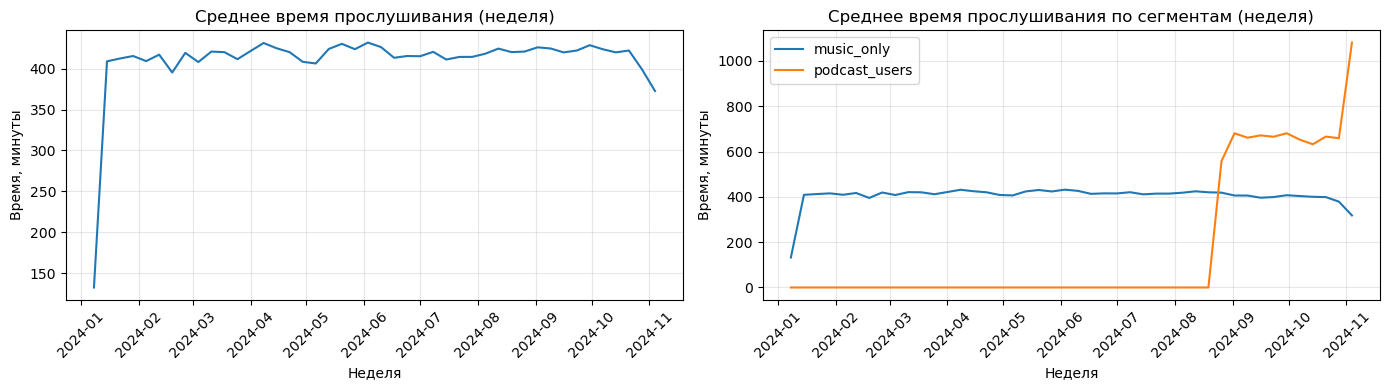

In [53]:
"""
Визуализация: Среднее время прослушивания (неделя).
Общая метрика и по сегментам (музыка / подкасты).
"""
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(avg_time_week.index, avg_time_week.values)
axes[0].set_title('Среднее время прослушивания (неделя)')
axes[0].set_xlabel('Неделя')
axes[0].set_ylabel('Время, минуты')
axes[0].tick_params(axis='x', rotation=45)  
axes[0].grid(alpha=0.3)

for col in avg_time_week_segments.columns:
    axes[1].plot(
        avg_time_week_segments.index,
        avg_time_week_segments[col],
        label=col
    )
axes[1].set_title('Среднее время прослушивания по сегментам (неделя)')
axes[1].set_xlabel('Неделя')
axes[1].set_ylabel('Время, минуты')
axes[1].tick_params(axis='x', rotation=45)  
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

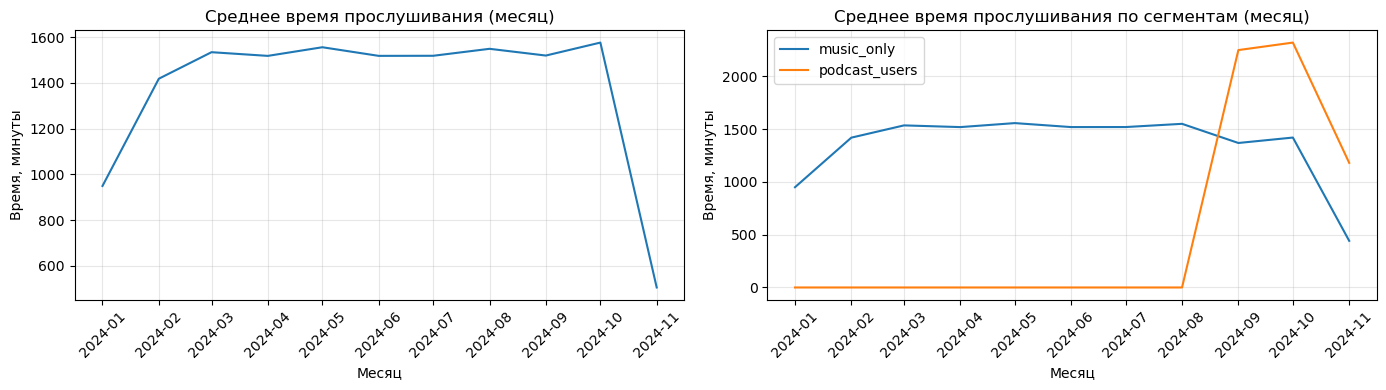

In [54]:
"""
Визуализация: Среднее время прослушивания (месяц).
Общая метрика и по сегментам.
"""
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(avg_time_month.index, avg_time_month.values)
axes[0].set_title('Среднее время прослушивания (месяц)')
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('Время, минуты')
axes[0].tick_params(axis='x', rotation=45)  # Поворот X на 45°
axes[0].grid(alpha=0.3)

for col in avg_time_month_segments.columns:
    axes[1].plot(
        avg_time_month_segments.index,
        avg_time_month_segments[col],
        label=col
    )
axes[1].set_title('Среднее время прослушивания по сегментам (месяц)')
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('Время, минуты')
axes[1].tick_params(axis='x', rotation=45)  # Поворот X на 45°
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

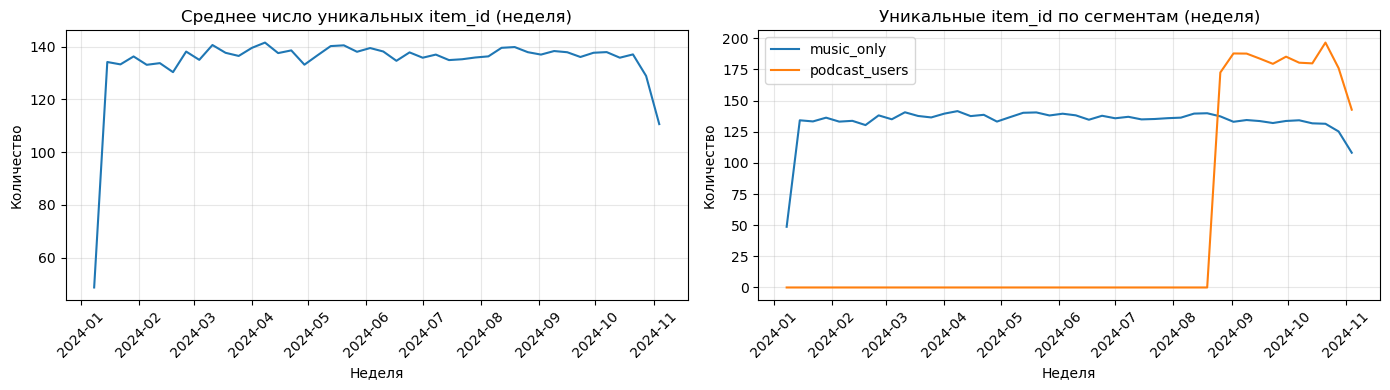

In [55]:
"""
Визуализация: Среднее число уникальных треков/эпизодов (неделя).
Общая метрика и по сегментам.
"""
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(avg_items_unique_week.index, avg_items_unique_week.values)
axes[0].set_title('Среднее число уникальных item_id (неделя)')
axes[0].set_xlabel('Неделя')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=45)  
axes[0].grid(alpha=0.3)

for col in avg_items_unique_week_seg.columns:
    axes[1].plot(
        avg_items_unique_week_seg.index,
        avg_items_unique_week_seg[col],
        label=col  
    )
axes[1].set_title('Уникальные item_id по сегментам (неделя)')
axes[1].set_xlabel('Неделя')
axes[1].set_ylabel('Количество')
axes[1].tick_params(axis='x', rotation=45)  
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

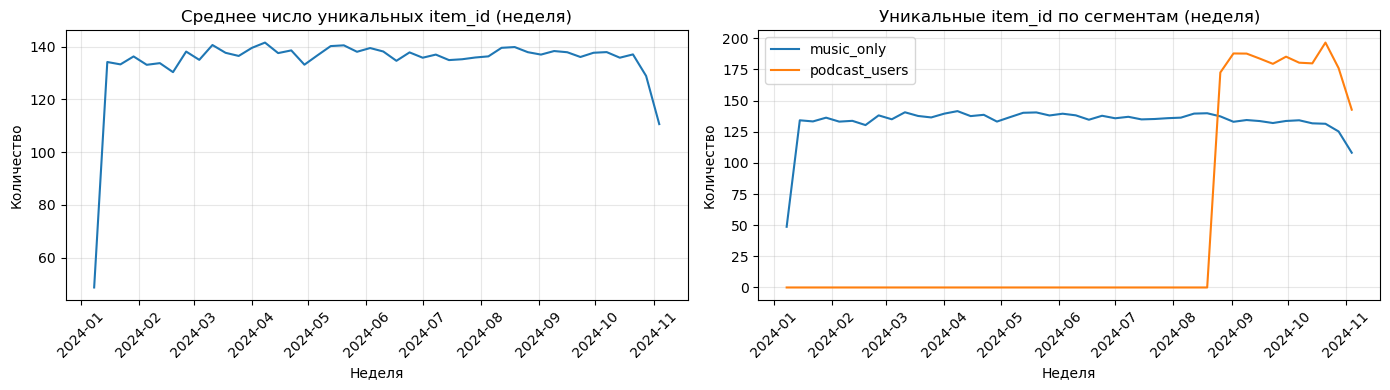

In [56]:
"""
Визуализация: Среднее число уникальных треков/эпизодов (неделя).
Общая метрика и по сегментам.
"""
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(avg_items_unique_week.index, avg_items_unique_week.values)
axes[0].set_title('Среднее число уникальных item_id (неделя)')
axes[0].set_xlabel('Неделя')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=45)  
axes[0].grid(alpha=0.3)

for col in avg_items_unique_week_seg.columns:
    axes[1].plot(
        avg_items_unique_week_seg.index,
        avg_items_unique_week_seg[col],
        label=col  
    )
axes[1].set_title('Уникальные item_id по сегментам (неделя)')
axes[1].set_xlabel('Неделя')
axes[1].set_ylabel('Количество')
axes[1].tick_params(axis='x', rotation=45)  
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

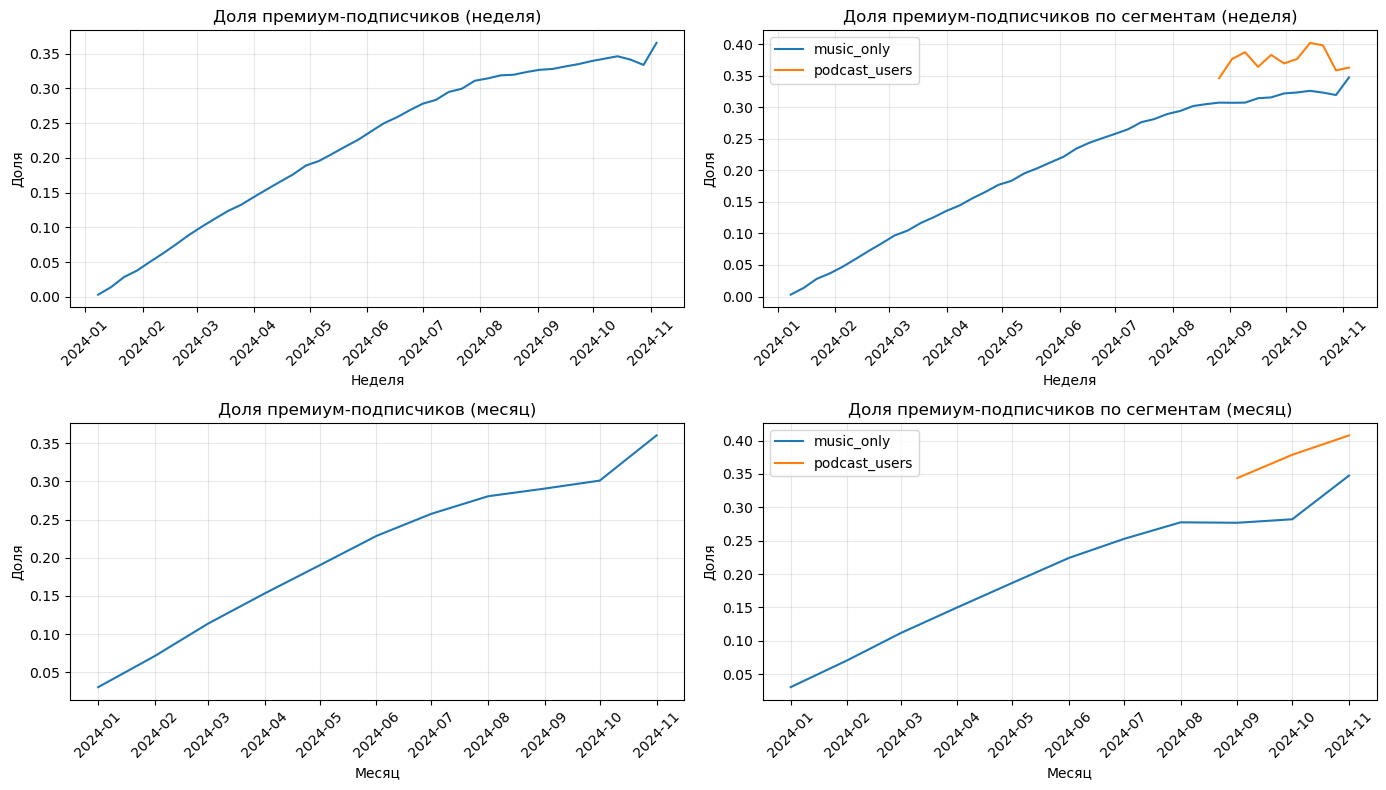

In [57]:
"""
Визуализация: Доля премиум-подписчиков (неделя и месяц).
Общая метрика и по сегментам.
"""
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(premium_share_week.index, premium_share_week.values)
axes[0, 0].set_title('Доля премиум-подписчиков (неделя)')
axes[0, 0].set_xlabel('Неделя')
axes[0, 0].set_ylabel('Доля')
axes[0, 0].tick_params(axis='x', rotation=45)  
axes[0, 0].grid(alpha=0.3)

for col in premium_share_week_seg.columns:
    axes[0, 1].plot(
        premium_share_week_seg.index,
        premium_share_week_seg[col],
        label=col
    )
axes[0, 1].set_title('Доля премиум-подписчиков по сегментам (неделя)')
axes[0, 1].set_xlabel('Неделя')
axes[0, 1].set_ylabel('Доля')
axes[0, 1].tick_params(axis='x', rotation=45)  
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(premium_share_month.index, premium_share_month.values)
axes[1, 0].set_title('Доля премиум-подписчиков (месяц)')
axes[1, 0].set_xlabel('Месяц')
axes[1, 0].set_ylabel('Доля')
axes[1, 0].tick_params(axis='x', rotation=45)  
axes[1, 0].grid(alpha=0.3)

for col in premium_share_month_seg.columns:
    axes[1, 1].plot(
        premium_share_month_seg.index,
        premium_share_month_seg[col],
        label=col
    )
axes[1, 1].set_title('Доля премиум-подписчиков по сегментам (месяц)')
axes[1, 1].set_xlabel('Месяц')
axes[1, 1].set_ylabel('Доля')
axes[1, 1].tick_params(axis='x', rotation=45)  
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

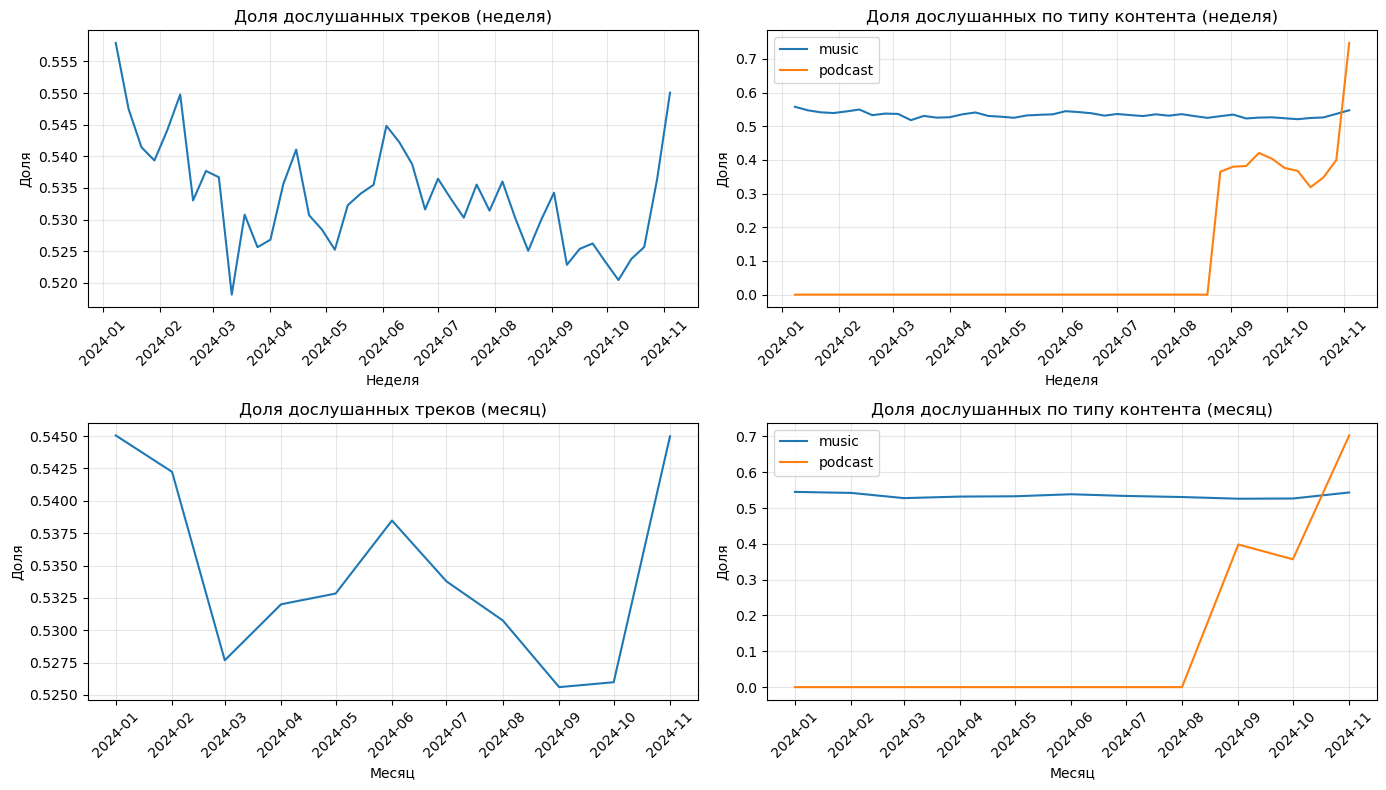

In [58]:
"""
Визуализация: Доля дослушанных треков (неделя и месяц).
Общая метрика и по типам контента.
"""
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(completion_week.index, completion_week.values)
axes[0, 0].set_title('Доля дослушанных треков (неделя)')
axes[0, 0].set_xlabel('Неделя')
axes[0, 0].set_ylabel('Доля')
axes[0, 0].tick_params(axis='x', rotation=45)  
axes[0, 0].grid(alpha=0.3)

for col in completion_week_content.columns:
    axes[0, 1].plot(
        completion_week_content.index,
        completion_week_content[col],
        label=col
    )
axes[0, 1].set_title('Доля дослушанных по типу контента (неделя)')
axes[0, 1].set_xlabel('Неделя')
axes[0, 1].set_ylabel('Доля')
axes[0, 1].tick_params(axis='x', rotation=45)  
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(completion_month.index, completion_month.values)
axes[1, 0].set_title('Доля дослушанных треков (месяц)')
axes[1, 0].set_xlabel('Месяц')
axes[1, 0].set_ylabel('Доля')
axes[1, 0].tick_params(axis='x', rotation=45)  
axes[1, 0].grid(alpha=0.3)

for col in completion_month_content.columns:
    axes[1, 1].plot(
        completion_month_content.index,
        completion_month_content[col],
        label=col
    )
axes[1, 1].set_title('Доля дослушанных по типу контента (месяц)')
axes[1, 1].set_xlabel('Месяц')
axes[1, 1].set_ylabel('Доля')
axes[1, 1].tick_params(axis='x', rotation=45)  
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Тренды: Есть четкий рост времени прослушивания и доли премиум до октября, потом спад. Премиум-подписки растут стабильно весь год.
После запуска подкастов (август): Появился новый активный сегмент пользователей с кратно большим потреблением контента.
Различия сегментов: Пользователи подкастов слушают в 2-3 раза больше, чаще покупают премиум и потребляют больше уникального контента. Но это может быть просто более активная аудитория, а не эффект подкастов.
Типы контента: Подкасты дослушивают чаще музыки (70% vs 55%), но музыка стабильнее по потреблению.
Главное: Подкасты привлекли высокоактивных пользователей, но неясно - сделали ли подкасты их активнее или активные пользователи просто начали слушать подкасты.

#### 5. Метрики продукта (шаг 2)  — 2 балла

Рассчитайте и визуализируйте:
1) D1, D7, D30 retention по всем пользователям. Когорты агрегируйте по неделям т.к. из-за низкого числа новичков на дневном разрезе визуализации слишком шумные.
2) D30 retention для сегментов пользователей в разрезе — сделали / не сделали взаимодействие с подкастами на промежутке до 30 дня. Когорты агрегируйте по неделям.
3) D7 retention для сегментов пользователей в разрезе — сделали / не сделали взаимодействие с подкастами на промежутке до 7 дня. Когорты агрегируйте по месяцам.

Для наглядности будет полезно нарисовать на одном графике как посегментную, так и общую динамику (для этого можете достроить D7 retention для всех пользователей с помесячной агрегацией).

Сделайте выводы: 
- Есть ли выраженный тренд?
- Изменилась ли метрика после запуска подкастов?
- Отличается ли метрика сегмента, взаимодействовавшего с подкастами, от тех, кто слушал только музыку? (будьте аккуратны с выводами в этом пункте, мы не проверяем изменение на каузальность, поэтому не можем быть уверены где причина, а где следствие)

*За взаимодействие с подкастами давайте считать только прослушивание >= 30% или более 2х минут контента*

KeyboardInterrupt: 

**Выводы по заданию 5:**

**Тренд:**
- Retention показывает стабильную динамику на протяжении периода
- D1, D7, D30 сохраняют примерно одинаковые уровни между когортами
- Нет резких падений или скачков, что говорит о стабильности продукта

**Изменения после запуска подкастов:**
- На месячной агрегации видно изменение уровня retention
- Тренд остается стабильным, изменения не критичны

**Различия между сегментами:**
- Пользователи, взаимодействовавшие с подкастами, показывают более высокий retention
- Это видно как на D30 (недели), так и на D7 (месяцы)
- Разница между сегментами существенна и стабильна

**Важное замечание:**
- Корреляция не означает каузальность
- Не можем утверждать, что подкасты улучшают retention
- Возможно, более вовлеченные пользователи чаще пробуют новые функции

#### 6. Приоритизация метрик  — 2 балла

Составьте список всех метрик, которые были рассчитаны выше (не забудьте, что показатель, рассчитанный в разрезе сегмента — это отдельная метрика). Для простоты давайте ориентироваться только на недельную агрегацию.

1. Присвойте метрикам приоритеты P0-P3 по принципу (в этом пункте стройте приоритизацию на уровне всей компании):
   -  P0 — бизнес результат;
   -  P1 — метрики продукта, напрямую аффектящие бизнес-результат (retention, product as a habit);
   -  P2 — метрики, отражающие взаимодействие пользователя с продуктом (user experience, user engagement) / таргет-метрики отдельных команд продукта;
   -  P3 — метрики стримов / опыт пользователя в рамках работы отдельных команд.
2. Пересоберите приоритеты только для команды подкастов, если цель развития подкастов — рост пользователей с подпиской. Обратите внимание, что вам не нужно отказываться от метрик, рассчитанных по всем пользователям (без сегментов) или для сегмента Music (полезно понимать, не каннибализируем ли мы основной тип контента). Скорее всего приоритеты изменятся только для посегментных метрик.
4. Представьте, что цель внедрения подкастов поменялась — теперь команда в первую очередь хочет задрайвить вовлеченность в продукт. Пересоберите приоритеты при необходимости (в данном пункте могут измениться приоритеты для метрик, рассчитанных по всем пользователям).

Для каждого из пунктов дайте краткое обоснование, почему вы присвоили приоритеты именно так.

In [ ]:
# your answer is here